In [1]:
%autosave 60
%cd ..
%reload_ext autoreload
%autoreload 2

Autosaving every 60 seconds
/Users/yulia/Library/CloudStorage/Dropbox/MTC/PY projects hw/_Math/14_EDA_Terrorism_ds


# Домашнее задание EDA | МТС Тета
-----
- Нужно провести EDA любого датасета на ваше усмотрение в специально подготовленном ipynb
- В этом ноутбуке будут блоки под разные типы графиков
- Нужно выбрать такой датасет, который позволит построить каждый из этих графиков корректно
- В ноутбуке так же будет дополнительное поле для графика на ваш выбор. В нем должен быть график, который не был построен ранее в ноутбуке (другой тип графика)
- Ноутбук должен отбегать в режиме run all, а так же сохранять все изображения шаблонным образом, как заложено в ноутбуке
- Для каждого графика должны быть написаны выводы
- __Вместе с ноутбуком нужно сдать сохраненные изображения (проверьте корректность их сохранения перед отправкой ДЗ)__
- изображения должны быть в формате png или jpeg. Не сохраняйте изображения в html (так делает plotly)
____
**Критерии оценки**
- Вы построили все основные графики без критических ошибок – 8 баллов
- Вы выполнили пункт 1, а так же построили дополнительный график - 10 баллов
- Доп. баллы выставляются за победу в tinder игре – подробности будут позже. Но чтобы в ней победить, ваш график должен оказаться самым красивым. 
- Доп. Баллы получат топ 10 человек итогового рейтинга. 
---
- Максимум 10 баллов (и +5 дополнительных)
- 1-4 балла: незачет
- 5-6 баллов: 3, незачет
- 7-8 баллов: 4, зачет
- 9-10 баллов: 5, зачет

## подготовка

In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sb
from matplotlib.ticker import PercentFormatter

from src.plot_utils import *
from src.translation_utils import translate_attack_types


plt.style.use("styles/plot_style.mplstyle")

In [3]:
# подставьте ваше имя и фамилию в эту переменную как в примере, (например Максим_Шаланкин)
image_name_prefix = 'Юлия_Никитина'

# можно поменять, а можно оставить - сюда будут сохраняться изображения
path_to_save_images = 'images'

In [4]:
os.makedirs(path_to_save_images, exist_ok=True)

### Global Terrorism datased (1980-2017)

In [5]:
# обработка сырого датасета сделана в ноутбуке 01_data_preparation.ipynb
# тут загрузка чистого датасета:

df = pd.read_csv('data/terrorism_clean.csv', encoding='latin1', low_memory=False)


In [6]:
# типы терактов: перевод на русский

df = translate_attack_types(df)

## (1) line plot

**Динамика видов атак по годам**

In [75]:
# количество терактов по годам
attack_counts_by_year = (
    df[df['attack_type'].isin(
        df['attack_type'].value_counts().head(5).index)]
    .groupby(['year','attack_type'])
    .size().reset_index(name='count'))


In [8]:
# количество пострадавших по годам
victim_total_by_year = (df.groupby('year')['victims'].sum().reset_index())

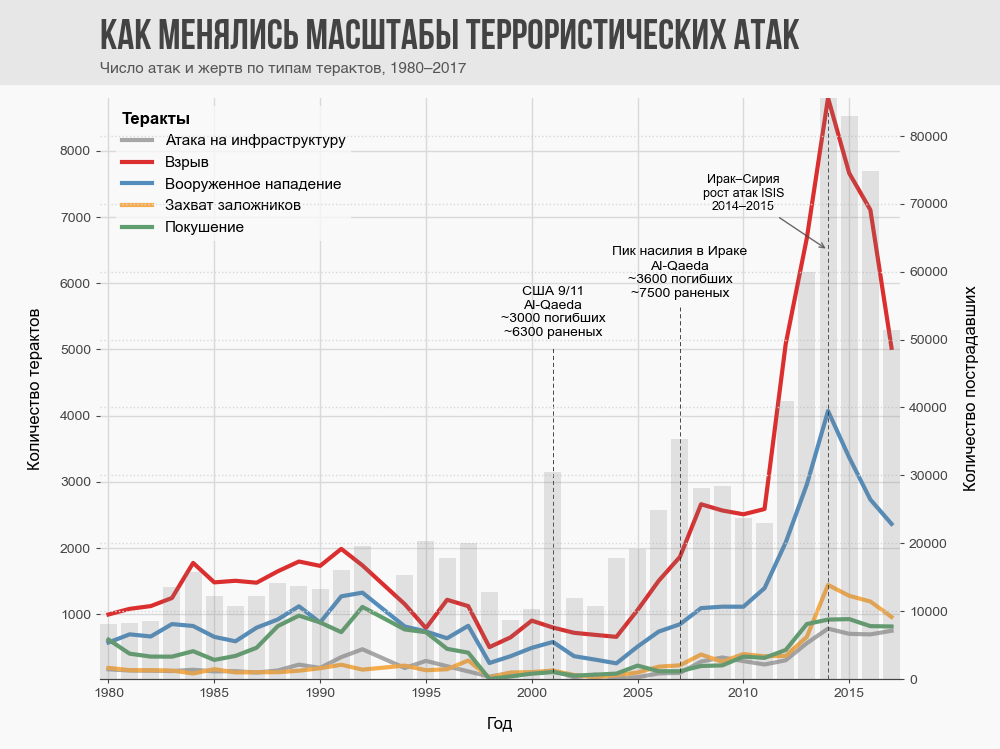

In [9]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# barplot: количество пострадавших по годам
ax2.bar(
    victim_total_by_year['year'],
    victim_total_by_year['victims'],
    color='grey', alpha=0.2, width=0.8)

# lineplot: динамика типов терактов
sb.lineplot(
    data=attack_counts_by_year,
    x='year',
    y='count',
    hue='attack_type', 
    palette=ATTACK_COLORS,
    linewidth=3, ax=ax1, alpha=1)

# события
ax1.axvline(2001, ymax=0.57, color="black", linestyle="--", linewidth=0.5)
ax1.axvline(2007, ymax=0.64, color="black", linestyle="--", linewidth=0.5)
ax1.axvline(2014, ymax=0.98, color="black", linestyle="--", linewidth=0.5)

ax1.text(2001, 5200, "США 9/11\nAl-Qaeda\n~3000 погибших\n~6300 раненых", ha="center", fontsize=10)
ax1.text(2007, 5800, "Пик насилия в Ираке\nAl-Qaeda\n~3600 погибших\n~7500 раненых", ha="center", fontsize=10)

ax1.annotate(
    "Ирак–Сирия\nрост атак ISIS\n2014–2015",
    xy=(2014, 6500),      # точка, куда указывает стрелка
    xytext=(2010, 7100), 
    fontsize=9,
    ha="center",
    arrowprops=dict(arrowstyle="->", lw=1, color="#444444", alpha=0.8)
)

ax1.grid(True, linestyle="-")
ax2.grid(True, linestyle=":")

ax1.set_xlabel("Год\n")
ax1.set_ylabel("Количество терактов")
ax2.set_ylabel("Количество пострадавших")

style_legend(ax1, 'Теракты', alpha=0.8, loc='tl', shift_x=0.01)
style_title(ax1, "Как менялись масштабы террористических атак", 
                 "Число атак и жертв по типам терактов, 1980–2017")


fig.savefig(os.path.join(path_to_save_images, f'{image_name_prefix}_image_1.png'),
                dpi=300, bbox_inches="tight")
plt.show()

#### **выводы** (1):
С 1980-х до начала 2000-х террористические атаки происходили в основном в рамках региональных конфликтов, общее число атак и жертв менялось умеренно.

В начале XXI века ситуация изменилась. В 2001 году глобальную статистику по числу жертв резко поднял один очень крупный теракт – атака на Башни-близнецы в США (9/11). Общее число пострадавших составило более 9000 человек (около 3000 погибших и более 6000 раненых).

После 2012 года начинается устойчивый рост террористической активности. На графике видно резкое увеличение числа атак и пострадавших, связанное с активностью радикальных группировок на Ближнем Востоке, прежде всего в Ираке и Сирии (ISIS).

Рост происходит главным образом за счет увеличения числа взрывов и вооруженных нападений. В этот же период заметно возрастает количество случаев захвата заложников. После 2015 года показатели постепенно снижаются.

## (2) (bar plot или stacked bar plot)

**Типы атак по террористическим организациям**

In [10]:
# уберем неизвестные группировки и типы атак
df_clean = df[
    (df['group_name'] != 'Unknown') &
    (df['attack_type'] != 'Unknown')].copy()

# топ группировок
top_org = (df_clean['group_name'].value_counts().head(10).index)

# топ типов атак
top_attacks = (df_clean['attack_type'].value_counts().head(5).index)

In [11]:
# создаем колонку, где редкие типы атак объединяются в Other
df_clean['attack_type_grouped'] = df_clean['attack_type']

df_clean.loc[
    ~df_clean['attack_type'].isin(top_attacks),
    'attack_type_grouped'
] = 'Другое'

In [12]:
# сборка таблицы
table = (df_clean[df_clean['group_name'].isin(top_org)]
        .groupby(['group_name','attack_type_grouped'])
        .size().unstack(fill_value=0))

# сортировка
table = table[table.sum().sort_values(ascending=False).index]
table = table.loc[table.sum(axis=1).sort_values(ascending=False).index]

# проценты
table_pct = table.div(table.sum(axis=1), axis=0)

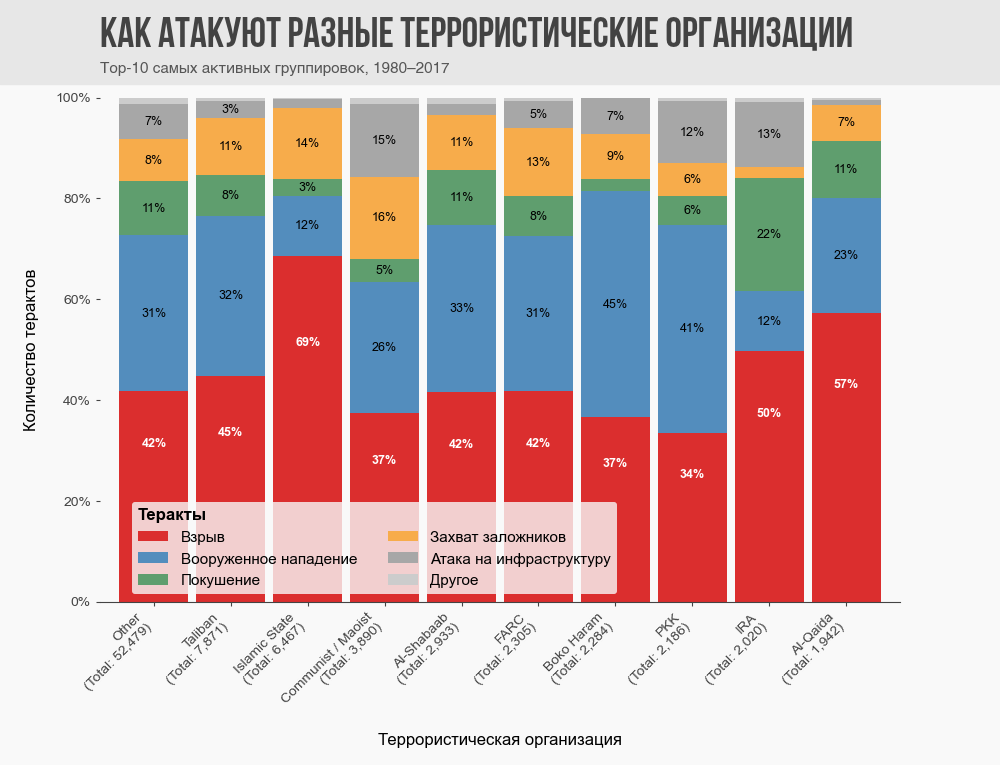

In [13]:
fig, ax = plt.subplots()
fig.subplots_adjust(top=0.82, bottom=0.1)

# stacked bar plot
table_pct.plot(
    kind='bar',
    stacked=True,
    color=attack_palette(table_pct.columns),
    width=0.9,  
    ax=ax)

# подпишем проценты 
for container, attack_type in zip(ax.containers, table_pct.columns):

    for bar, value in zip(container, container.datavalues):
        if value < 0.03:
            continue

        x = bar.get_x() + bar.get_width()/2
        y = bar.get_y() + bar.get_height()/2

        if attack_type == "Взрыв":
            y = bar.get_y() + bar.get_height()*0.75
            text_color = "white"
            weight = "bold"
        else:
            text_color = "black"
            weight = "normal"

        ax.text(
            x, y,
            f"{value:.0%}",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
            fontweight=weight)

ax.yaxis.set_major_formatter(PercentFormatter(1))

# суммарное количество атак
totals = (df_clean[df_clean['group_name'].isin(table_pct.index)]
    .groupby('group_name').size())

# добавим в подписи x
new_labels = [f"{name}\n(Total: {int(totals.loc[name]):,})"
              for name in table_pct.index]

ax.set_xticklabels(new_labels, rotation=45, ha="right")

ax.set_xlabel("Террористическая организация\n")
ax.set_ylabel("Количество терактов")

style_legend(ax, 'Теракты', alpha=0.8, ncol=2, loc='bl', shift_x=0.03)
style_title(ax,
    "Как атакуют разные террористические организации",
    "Top-10 самых активных группировок, 1980–2017")


fig.savefig(os.path.join(path_to_save_images, f'{image_name_prefix}_image_2.png'),
                dpi=300, bbox_inches="tight")
plt.show()

#### **выводы** (2):
Взрывы – самый популярный тип атак у 7 из 9 наиболее активных террористических организаций. У Islamic State доля взрывов достигает 69% всех атак. На втором месте Al-Qaida – 57%, на третьем IRA (Ирландия) – около 50%.

При этом Boko Haram (Нигерия) и PKK (курдское движение в Турции и соседних странах) чаще используют вооруженные нападения, чем другие типы атак. Суммарно на взрывы и вооруженные нападения приходится больше половины всех терактов.

Талибан остается лидером по общему числу терактов за период 1980–2017 годов – всего 7,871 атак.

В категорию Other попали около 2900 менее известных группировок по всему миру. Вместе они совершили 52,479 терактов: больше, чем любая отдельная организация.

##  (3) (hist plot или pair plot или kde plot)

**Распределения типов атак по количеству жертв**

In [ ]:
# выбранные типы атак
selected_attack = ['Взрыв', 'Вооруженное нападение', 'Покушение', 'Захват заложников']

# сумма погибших по годам
killed_year = (
    df[df['attack_type'].isin(selected_attack)]
    .groupby(['year','attack_type'])['victims']
    .sum().reset_index())

# обрезаем хвост распределения
#p95 = killed_year['victims'].quantile(0.95)
#data_plot = killed_year[killed_year['victims'] <= p95]

,year,attack_type,victims
0,1980,Взрыв,3628.0
1,1980,Вооруженное нападение,3046.0
2,1980,Захват заложников,138.0
3,1980,Покушение,970.0
4,1981,Взрыв,3468.0
...,...,...,...
143,2016,Покушение,1716.0
144,2017,Взрыв,27646.0
145,2017,Вооруженное нападение,11866.0
146,2017,Захват заложников,3721.0


In [88]:
# вычисляем mean и median
means = killed_year.groupby('attack_type')['victims'].mean()
medians = killed_year.groupby('attack_type')['victims'].median()
medians

attack_type
Взрыв                    7432.0
Вооруженное нападение    4702.0
Захват заложников         309.0
Покушение                 935.0
Name: victims, dtype: float64

In [ ]:
# вычисляем mean и median
means = data_plot.groupby('attack_type')['victims'].mean()
medians = data_plot.groupby('attack_type')['victims'].median()

In [90]:
#data_plot.groupby('attack_type')['victims'].min()
killed_year.groupby('attack_type')['victims'].min()

attack_type
Взрыв                    3468.0
Вооруженное нападение    1970.0
Захват заложников          37.0
Покушение                 104.0
Name: victims, dtype: float64

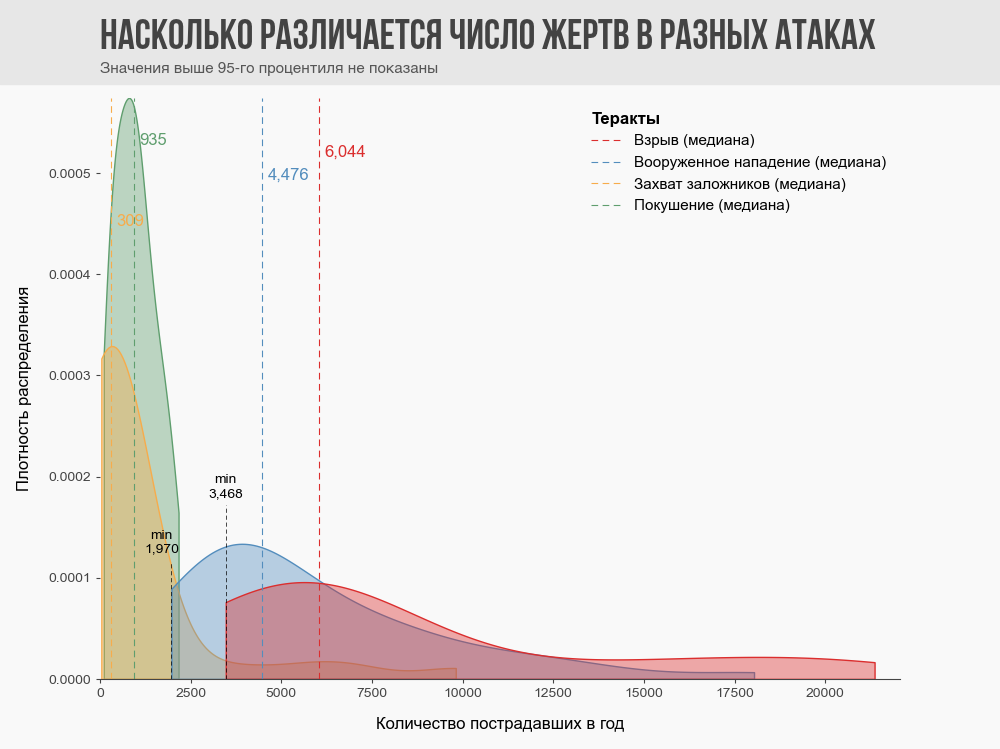

In [83]:
fig, ax = plt.subplots()

# KDE
ax = sb.kdeplot(data=data_plot, x='victims',
    hue='attack_type', palette=ATTACK_COLORS, fill=True,
    common_norm=False, alpha=0.4, cut=0)

plt.xlim(0, p95)

# линии медиан
for i, attack in enumerate(means.index):
    x = medians[attack]

    ax.axvline(x, 
        color=ATTACK_COLORS[attack],
        ls='--', lw=0.8,
        label=f"{attack} (медиана)")

    y_positions = {
        "Взрыв": 0.92,
        "Вооруженное нападение": 0.88,
        "Покушение": 0.94,
        "Захват заложников": 0.80}

    # подписи медианы
    ax.text(
        x+150,
        ax.get_ylim()[1] * y_positions[attack],
        f"{int(x):,}",
        color=ATTACK_COLORS[attack],
        ha="left", va="top",
        fontsize=12)

# минимумы
ax.axvline(3468, ymax=0.3, color="black", linestyle="--", linewidth=0.5)
ax.axvline(1970, ymax=0.2, color="black", linestyle="--", linewidth=0.5)

ax.text(3468, 0.000180, "min\n3,468", color='black', ha="center", fontsize=10)
ax.text(1700, 0.000125, "min\n1,970", color='black', ha="center", fontsize=10)

plt.xlabel("Количество пострадавших в год\n")
plt.ylabel("Плотность распределения")

style_legend(ax, 'Теракты', loc='tr')
style_title(ax,
    "Насколько различается число жертв в разных атаках",
    "Значения выше 95-го процентиля не показаны")


fig.savefig(os.path.join(path_to_save_images, f'{image_name_prefix}_image_3.png'),
                dpi=300, bbox_inches="tight")
plt.show()

#### **выводы** (3): 
- Взрывы оказываются самым смертоносным типом атак. 
Медианное число потерпевших от взрывов в год составляет около 6 044, а в отдельные годы потери достигают десятков тысяч. Даже минимальное годовое число жертв взрывов (погибшими и ранеными) за период 1980–2017 не опускалось ниже 3 468.

- Вооруженные нападения занимают второе место по масштабам потерь. Их медианное значение составляет около 4 476 жертв в год, а минимальное около 1 970.

- Покушения и захваты заложников приводят к значительно меньшим потерям. Их медианные значения: примерно 935 и 309 жертв в год.

Наиболее крупные человеческие потери связаны прежде всего со взрывами и вооруженными нападениями, а покушения и захваты заложников обычно имеют более ограниченные последствия.

##  (4) heatmap plot

**Смертность от разных типов атак по регионам**

In [17]:
# выберем top-5 типов атак
top_attacks = (
    df[df['attack_type'] != 'Unknown']['attack_type']
    .value_counts().head(5).index)

# таблица по количеству жертв
table = (df[df['attack_type'].isin(top_attacks)]
    .groupby(['region', 'attack_type'])['victims']
    .sum().unstack(fill_value=0))

# порядок типов атак
table = table[top_attacks]

# сортировка регионов
table = table.loc[table.sum(axis=1).sort_values(ascending=False).index]

table = table.astype(int)
table

attack_type,Взрыв,Вооруженное нападение,Покушение,Захват заложников,Атака на инфраструктуру
region,,,,,
Middle East & North Africa,266584,40718,9047,15778,995
South Asia,139284,63608,11848,7223,1693
Sub-Saharan Africa,44168,57813,3367,10038,2061
South America,14961,20339,4681,1252,377
Southeast Asia,21766,12944,2367,964,354
Central America & Caribbean,5109,28256,1679,339,190
Western Europe,13495,2432,2065,458,336
Eastern Europe,11936,3898,777,2007,96
North America,1930,2102,254,255,444


In [18]:
# примерное население 
region_population = {
    "South Asia": 1_850_000_000,
    "East Asia": 1_640_000_000,
    "Southeast Asia": 650_000_000,
    "Sub-Saharan Africa": 1_030_000_000,
    "Middle East & North Africa": 440_000_000,
    "Western Europe": 196_000_000,
    "Eastern Europe": 292_000_000,
    "Central America & Caribbean": 180_000_000,
    "South America": 430_000_000,
    "North America": 365_000_000,
    "Central Asia": 72_000_000,
    "Australasia & Oceania": 41_000_000
}

In [19]:
# сумма жертв по региону
victims_region = (df.groupby("region")["victims"].sum().reset_index())

# население региона из словаря
victims_region["population"] = victims_region["region"].map(region_population)

# доля жертв в каждом регионе от общего числа жертв
victims_region["victim_share"] = victims_region["victims"] / victims_region["victims"].sum()

# доля населения региона от общего числа по миру
victims_region["population_share"] = victims_region["population"] / sum(region_population.values())

# индекс терроризма (отношение доли жертв к доли мирового населения)
victims_region["terrorism_intensity"] = (
    victims_region["victim_share"] /
    victims_region["population_share"])

# сортировка регионов по индексу терроризма
victims_region.sort_values("terrorism_intensity", ascending=False)

# сортировка таблицы для хитмап
region_order = (victims_region.sort_values("terrorism_intensity", ascending=False)["region"])
table_sorted = table.loc[region_order]

# таблица индекса терроризма
heat_index = (victims_region.set_index("region").loc[region_order][["terrorism_intensity"]])

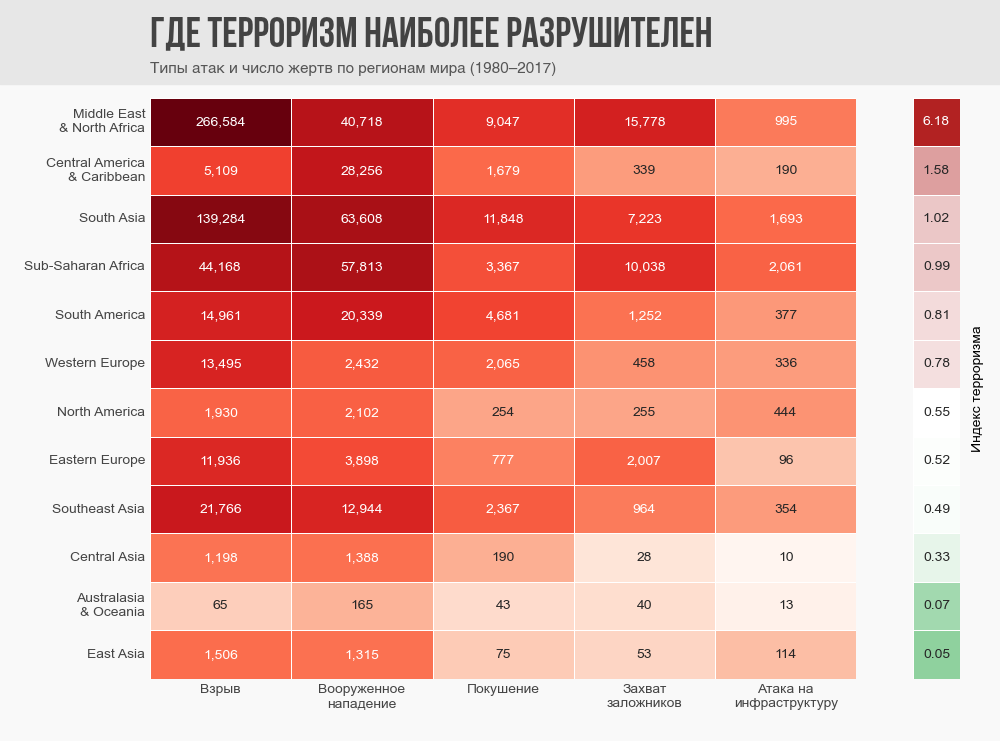

In [20]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, gridspec_kw={"width_ratios":[6,0.4], "wspace":0.15})
plt.subplots_adjust(left=0.15, right=0.96)

# основной heatmap 
sb.heatmap(table_sorted,
    annot=True,
    fmt=",",
    cmap="Reds",
    norm=LogNorm(vmin=max(table_sorted.min().min(),1),
                 vmax=table_sorted.max().max()),
    lw=0.5, cbar=False, ax=axes[0])

# перенос строк в подписях X 
new_xlabels = [
    "Взрыв",
    "Вооруженное\nнападение",
    "Покушение",
    "Захват\nзаложников",
    "Атака на\nинфраструктуру"
    ]

axes[0].set_xticklabels(new_xlabels, rotation=0)
axes[0].set_yticklabels(
    [r.replace(" & ", "\n& ") for r in table_sorted.index], rotation=0)

# колонка индекса терроризма
sb.heatmap(
    heat_index,
    cmap = sb.blend_palette(["#8fd19e", "white", "#b22222"], as_cmap=True),
    norm=LogNorm(
        vmin=heat_index.min().values[0],
        vmax=heat_index.max().values[0]),
    annot=True,
    fmt=".2f",
    lw=0.5, cbar=False, ax=axes[1]
    )

# убираем лишние оси
axes[0].set_xlabel(" ")
axes[0].yaxis.label.set_visible(False)
axes[0].tick_params(axis="both", length=0)
axes[1].set_yticks([])
axes[1].set_xticks([])

# вертикальная подпись
axes[1].set_ylabel("Индекс терроризма", rotation=90, labelpad=0.2, fontsize=10)
axes[1].yaxis.set_label_coords(1.5, 0.5)

style_title(axes[0],
    "Где терроризм наиболее разрушителен",
    "Типы атак и число жертв по регионам мира (1980–2017)")


fig.savefig(os.path.join(path_to_save_images, f'{image_name_prefix}_image_4.png'),
                dpi=300, bbox_inches="tight")
plt.show()

#### **выводы** (4): 
Наибольшее число жертв терактов приходится на Ближний Восток и Северную Африку. Особенно выделяются взрывы (более 266 тысяч жертв), что значительно превышает показатели других типов атак и регионов.

Южная Азия занимает второе место по общему числу жертв. Как и на Ближнем Востоке, основной вклад здесь также вносят взрывы, но заметную долю составляют и вооруженные нападения.

В Африке к югу от Сахары число жертв от вооруженных нападений (около 58 тысяч) даже превышает потери от взрывов. Это указывает на более частое использование прямых вооруженных атак в этом регионе.

В регионах Европы и Америки общее число жертв существенно ниже. Здесь также доминируют взрывы и вооруженные нападения, тогда как другие типы атак приводят к значительно меньшим потерям.

В Северной Америке, Восточной Европе, Восточной Азии (Китай, Япония, Южная и Северная Корея и т.д.) число жертв терактов относительно низкое.

Согласно индексу терроризма самый опасным регионом с большим отрывом от других является Ближний восток и Северная Африка, а Центральная и Восточная Азия, Австралазия и Океания – самые спокойные регионы мира. 

##  (5) plot  на ваш выбор

In [21]:
# уберем неизвестные и безымянные группы
df_plot = df[~df["group_name"].isin(["Other", "Unknown"])].copy()

# год + месяц -> в datetime
df_plot["date"] = pd.to_datetime(
    dict(year=df_plot.year, month=df_plot.month, day=1))

# интересующие типы атак
df_plot = df_plot[df_plot["attack_type"].isin([
    "Взрыв", "Вооруженное нападение"])]

events = (df_plot
    .groupby(["group_name", "date", "attack_type"])
    .agg(events=("event_id", "count"),
         victims=("victims", "sum")).reset_index())

# список самых активных групп по числу событий
top_groups = (events.groupby("group_name")["events"]
    .sum().sort_values(ascending=False).head(10).index)

events = events[events["group_name"].isin(top_groups)]

# порядок групп
order = (events.groupby("group_name")["events"]
    .sum().sort_values(ascending=False).index)

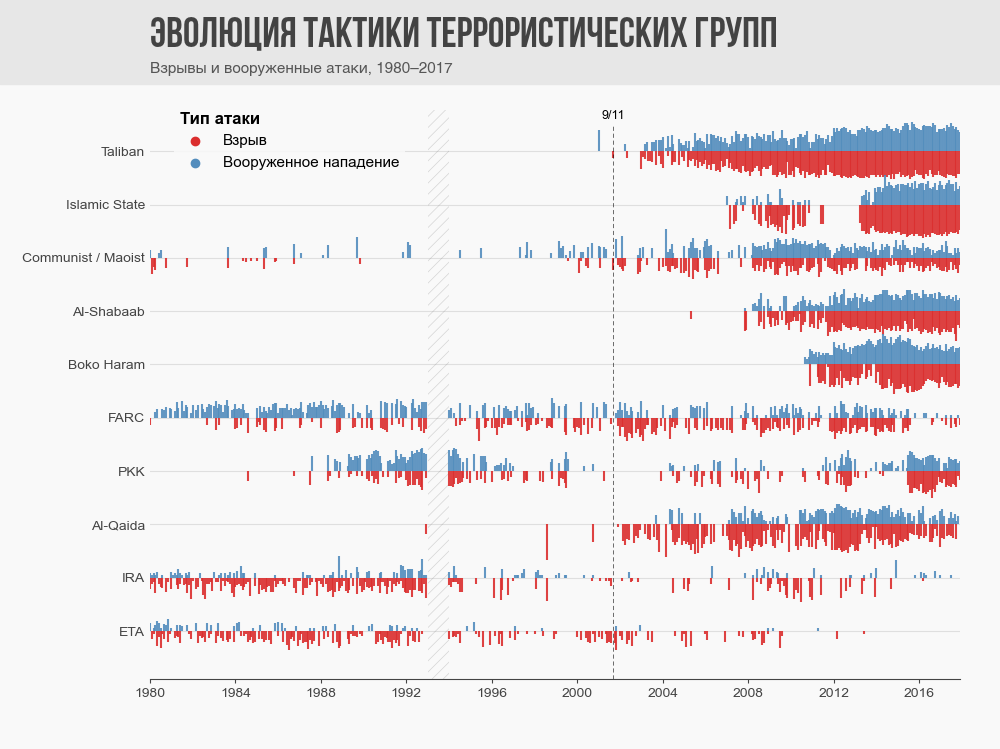

In [26]:
fig, ax = plt.subplots()
plt.subplots_adjust(left=0.15, right=0.96)

groups = list(order)
group_to_y = {g: i for i, g in enumerate(groups)}

for attack, direction, color in [
    ("Взрыв", 1, "#db2e2e"),
    ("Вооруженное нападение", -1, "#538dbd")
    ]:

    subset = events[events["attack_type"] == attack]

    y = subset["group_name"].map(group_to_y)

    ax.vlines(subset["date"],
        y, y + direction * np.log1p(subset["victims"]) * 0.08,
        color=color, alpha=0.9, lw=1.5)

# отметим 9/11
ax.axvline(pd.Timestamp("2001-09-11"), color="black", linestyle="--", 
    ymax=0.955, linewidth=0.5, alpha=0.8)
ax.text(pd.Timestamp("2001-09-11"), -0.6,
    "9/11", ha="center", fontsize=9)

# пропущены данные за 1993 в датасете
ax.axvspan(
    pd.Timestamp("1993-01-01"),
    pd.Timestamp("1993-12-31"),
    facecolor="none",
    edgecolor="grey",
    hatch="///",
    alpha=0.3, linewidth=0, ymax=0.98)

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_ylim(len(groups) -0.1, -1)

ax.grid(axis="y", linestyle="-", linewidth=0.8, alpha=0.8)

ax.yaxis.label.set_visible(False)

# кастомный label
ax.set_xlabel(" \n")
legend_elements = [
    plt.scatter([], [], color="#db2e2e", label="Взрыв"),
    plt.scatter([], [], color="#538dbd", label="Вооруженное нападение")]
ax.tick_params(axis="y", length=0)

style_legend(ax, "Тип атаки", loc="tl", handles=legend_elements, shift_x=0.02)
style_title(ax,
    "Эволюция тактики террористических групп",
    "Взрывы и вооружeнные атаки, 1980–2017")


fig.savefig(os.path.join(path_to_save_images, f'{image_name_prefix}_image_5.png'),
                dpi=300, bbox_inches="tight")
plt.show()


#### **выводы** (5): 
Активность террористических группировок со временем меняется по интенсивности и по тактике. До 2000 года большинство представленных организаций действуют эпизодически, количество пострадавших обычно ограничено.

После 2001 года динамика меняется. Ряд группировок (прежде всего Al-Qaeda, Taliban и позднее Islamic State) начинают действовать более активно. При этом усиливается роль взрывов, которые чаще приводят к масштабным потерям. С начала 2010-х Islamic State устраивает большое число терактов со значительным количеством жертв, что контрастирует с более равномерной активностью других организаций.

В целом график показывает, что разные группы используют разные тактические профили. IRA и ETA действовали относительно стабильно на протяжении десятилетий, но примерно с середины 1990-х их атаки становятся заметно реже. В то же время Al-Qaeda, Taliban, Islamic State и Boko Haram активно проявляют себя уже в XXI веке, что связано с крупными региональными конфликтами и политическими кризисами.

# Итоговый вывод по всему датасету (по всему EDA)
Анализ базы **Global Terrorism Database**

Терроризм развивается волнами и тесно связан с крупными региональными конфликтами. До начала 2000-х уровень атак и жертв выглядит очень низким по сравнению началом XXI века. Самый резкий всплеск приходится на 2012–2015 годы – период активных конфликтов на Ближнем Востоке и роста ISIS.

Самые смертоносные типы атак – взрывы и вооружeнные нападения. Именно они формируют основные пики на графиках и дают наибольшее число жертв.

Отдельные группировки ведут себя по-разному. Некоторые действуют десятилетиями и постепенно сходят на нет (IRA, ETA). Другие, наоборот, резко появляются на фоне конфликтов и быстро наращивают масштаб атак (Al-Qaeda, Taliban, ISIS или Boko Haram).

В итоге из данных видно довольно простую вещь: терроризм сильнее всего растeт там, где появляются затяжные войны и политические кризисы. Именно такие конфликты создают условия для появления новых группировок и всплесков насилия.

In [23]:
print('well done!')

well done!
